In [3]:
import Metrica_IO as mio
import Metrica_Viz as mviz

In [2]:
DATADIR = "data"
game_id = 2

In [3]:
events = mio.read_event_data(DATADIR, game_id)


In [4]:
# count the number of each event type in the data
print(events["Type"].value_counts())


PASS              964
CHALLENGE         311
RECOVERY          248
BALL LOST         233
SET PIECE          80
BALL OUT           49
SHOT               24
FAULT RECEIVED     20
CARD                6
Name: Type, dtype: int64


In [5]:
# Bit of housekeeping: unit conversion from metric data units to meters
events = mio.to_metric_coordinates(events)

# Get events by team
home_events = events[events["Team"] == "Home"]
away_events = events[events["Team"] == "Away"]

# Frequency of each event type by team
home_events["Type"].value_counts()
away_events["Type"].value_counts()

# Get all shots
shots = events[events["Type"] == "SHOT"]
home_shots = home_events[home_events.Type == "SHOT"]
away_shots = away_events[away_events.Type == "SHOT"]


In [8]:
# Look at frequency of each shot Subtype
home_shots["Subtype"].value_counts()


ON TARGET-SAVED        4
HEAD-OFF TARGET-OUT    4
OFF TARGET-OUT         2
ON TARGET-GOAL         2
HEAD-ON TARGET-GOAL    1
Name: Subtype, dtype: int64

In [9]:
away_shots["Subtype"].value_counts()


OFF TARGET-OUT         3
BLOCKED                2
ON TARGET-GOAL         2
ON TARGET-SAVED        2
OFF TARGET-HEAD-OUT    1
HEAD-OFF TARGET-OUT    1
Name: Subtype, dtype: int64

In [10]:
# Get the shots that led to a goal
home_goals = home_shots[home_shots["Subtype"].str.contains("-GOAL")].copy()
away_goals = away_shots[away_shots["Subtype"].str.contains("-GOAL")].copy()


In [11]:
# Add a column event 'Minute' to the data frame
home_goals["Minute"] = home_goals["Start Time [s]"] / 60.0


Text(-47.7, -3.400000000000003, '')

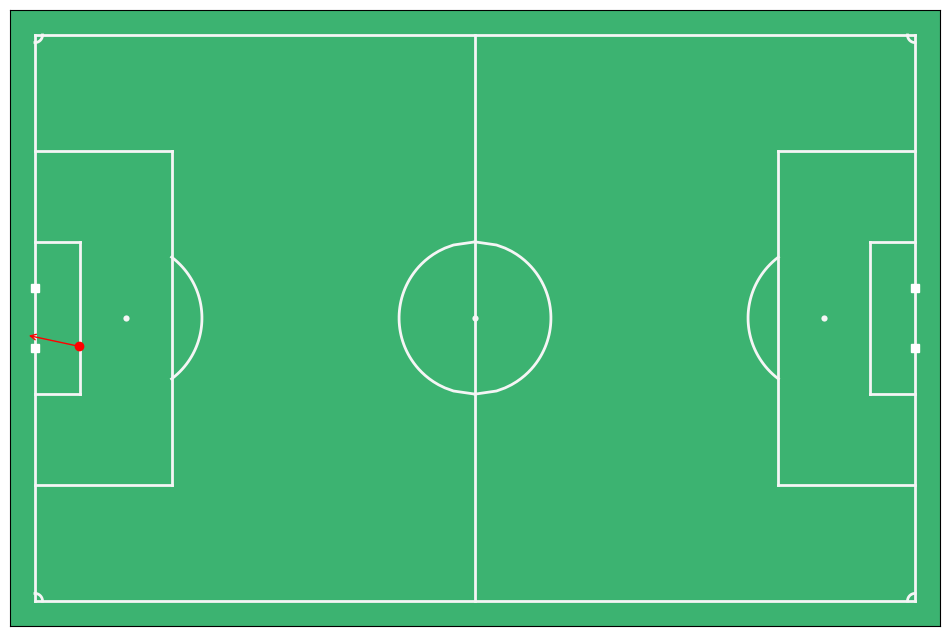

In [12]:
# Plot the first goal
fig, ax = mviz.plot_pitch()
ax.plot(events.loc[198]["Start X"], events.loc[198]["Start Y"], "ro")
ax.annotate(
    "",
    xy=events.loc[198][["End X", "End Y"]],
    xytext=events.loc[198][["Start X", "Start Y"]],
    alpha=0.6,
    arrowprops=dict(arrowstyle="->", color="r"),
)


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

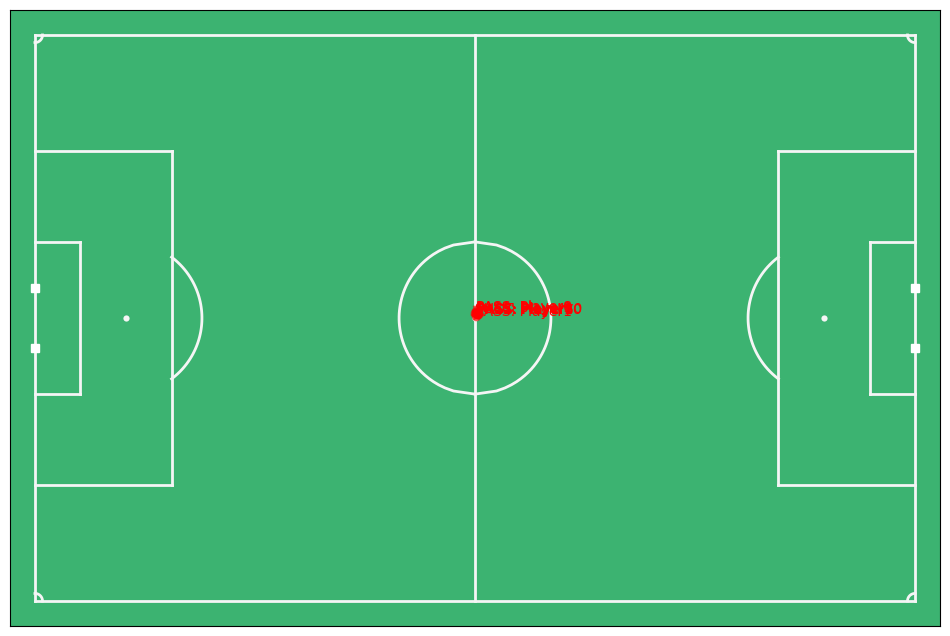

In [11]:
# plot passing move in run up to goal
mviz.plot_events(events.loc[190:198], indicators=["Marker", "Arrow"], annotate=True)


In [14]:
#### TRACKING DATA ####

# READING IN TRACKING DATA
tracking_home = mio.tracking_data(DATADIR, game_id, "Home")
tracking_away = mio.tracking_data(DATADIR, game_id, "Away")

# Look at the column namems
print(tracking_home.columns)

# Convert positions from metrica units to meters
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)


Reading team: home
Reading team: away
Index(['Period', 'Time [s]', 'Home_11_x', 'Home_11_y', 'Home_1_x', 'Home_1_y',
       'Home_2_x', 'Home_2_y', 'Home_3_x', 'Home_3_y', 'Home_4_x', 'Home_4_y',
       'Home_5_x', 'Home_5_y', 'Home_6_x', 'Home_6_y', 'Home_7_x', 'Home_7_y',
       'Home_8_x', 'Home_8_y', 'Home_9_x', 'Home_9_y', 'Home_10_x',
       'Home_10_y', 'Home_12_x', 'Home_12_y', 'Home_13_x', 'Home_13_y',
       'Home_14_x', 'Home_14_y', 'ball_x', 'ball_y'],
      dtype='object')


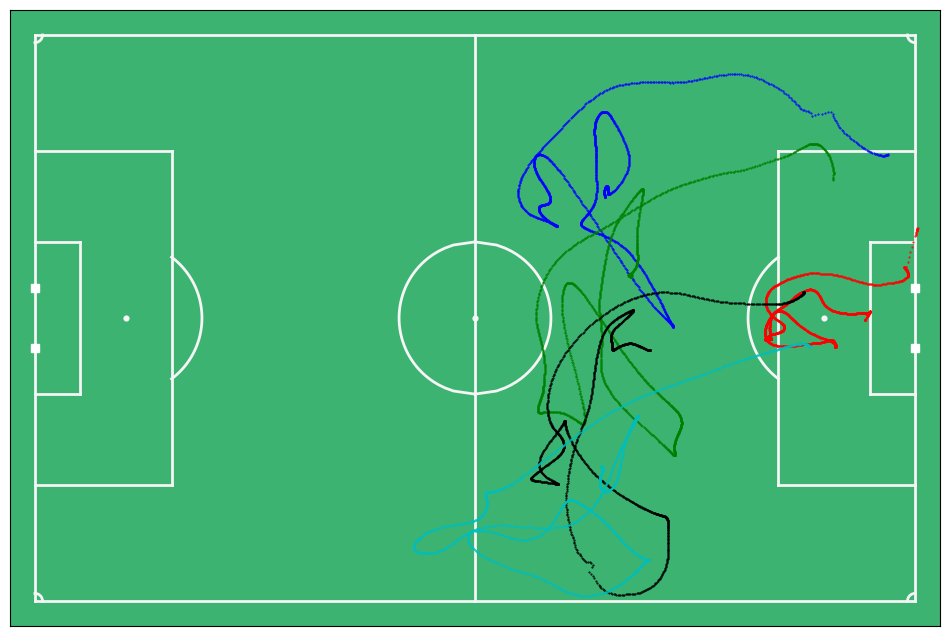

In [15]:
# Plot some player trajectories (players 11,1,2,3,4)
fig, ax = mviz.plot_pitch()
ax.plot(
    tracking_home["Home_11_x"].iloc[:1500],
    tracking_home["Home_11_y"].iloc[:1500],
    "r.",
    markersize=1,
)
ax.plot(
    tracking_home["Home_1_x"].iloc[:1500],
    tracking_home["Home_1_y"].iloc[:1500],
    "b.",
    markersize=1,
)
ax.plot(
    tracking_home["Home_2_x"].iloc[:1500],
    tracking_home["Home_2_y"].iloc[:1500],
    "g.",
    markersize=1,
)
ax.plot(
    tracking_home["Home_3_x"].iloc[:1500],
    tracking_home["Home_3_y"].iloc[:1500],
    "k.",
    markersize=1,
)
ax.plot(
    tracking_home["Home_4_x"].iloc[:1500],
    tracking_home["Home_4_y"].iloc[:1500],
    "c.",
    markersize=1,
)


# Formation Analysis

In [128]:
import pandas as pd
import numpy as np
import Metrica_Velocities as mvel
import importlib
import Metrica_IO as mio

importlib.reload(mio)


<module 'Metrica_IO' from 'd:\\HEC Paris\\M2\\Personal Project\\football-tactical-analysis\\Metrica_IO.py'>

In [129]:
# Define the data directory and game ID
DATADIR = "data"
GAME_ID = 2

# Load tracking and event data
tracking_home, tracking_away, events = mio.read_match_data(DATADIR, GAME_ID)

# Convert positions from Metrica units to meters
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)


Reading team: home
Reading team: away


In [130]:
tracking_home, tracking_away, events = mio.read_match_data(DATADIR, GAME_ID)

Reading team: home
Reading team: away


In [131]:
tracking_home

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_10_x,Home_10_y,Home_12_x,Home_12_y,Home_13_x,Home_13_y,Home_14_x,Home_14_y,ball_x,ball_y
Frame,,,,,,,,,,,,,,,,,,,,,
1,1,0.04,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0.08,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0.12,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0.16,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,0.20,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2,5646.08,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,NaN,NaN,0.40837,0.14449,0.51032,0.94554,0.27962,0.36700,NaN,NaN
141153,2,5646.12,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,NaN,NaN,0.40837,0.14449,0.51031,0.94626,0.28009,0.36718,NaN,NaN
141154,2,5646.16,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,NaN,NaN,0.40837,0.14449,0.51029,0.94711,0.28031,0.36726,NaN,NaN


In [132]:
print(tracking_home[tracking_home["Period"] == 2].shape)
print(tracking_away[tracking_away["Period"] == 2].shape)
print(events[events["Period"] == 2].shape)


d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  team.fillna(method="ffill", inplace=True)  # Forward fill missing positions
d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:57: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dt.fillna(method="bfill", inplace=True)  # Fill first row
d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  team.fillna(method="ffill", inplace=True)  # Forward fill missing positions
d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:57: FutureWarning: Series.fillna with '

In [133]:
def extract_player_positions(tracking_data, teamname):
    """
    Extracts (x, y) positions of all players for clustering.

    Parameters:
    -----------
    tracking_data : DataFrame
        Processed tracking data for a team.

    teamname : str
        "Home" or "Away"

    Returns:
    --------
    player_positions : DataFrame
        DataFrame containing only player positions (x, y).
    """
    # Select only player position columns (ignoring ball positions)
    player_columns = [
        col
        for col in tracking_data.columns
        if teamname in col and ("_x" in col or "_y" in col)
    ]

    # Extract only player positions
    player_positions = tracking_data[player_columns].copy()

    return player_positions


In [153]:
def select_11_active_players(player_positions):
    """
    Selects exactly 11 active players per frame, correctly handling substitutions.

    Parameters:
    -----------
    player_positions : DataFrame
        DataFrame containing player (x, y) positions for each frame.

    Returns:
    --------
    filtered_positions : DataFrame
        DataFrame containing only the 11 active players per frame.
    """
    filtered_positions = []

    for index, row in player_positions.iterrows():
        # Identify players currently on the field (not NaN)
        active_players = row.dropna().index.to_list()

        # Ensure we have exactly 11 players (22 columns)
        if len(active_players) >= 22:
            # Select the first 11 active players (22 columns: x and y)
            selected_players = active_players[:22]
            filtered_positions.append(row[selected_players])

    # Convert to DataFrame
    filtered_positions = pd.DataFrame(filtered_positions).reset_index(drop=True)

    # Ensure shape is correct
    if filtered_positions.shape[1] != 22:
        raise ValueError(
            f"Error: Expected 22 columns (11 players), got {filtered_positions.shape[1]}"
        )

    return filtered_positions


In [149]:
home = extract_player_positions(tracking_home, "Home")

In [154]:
home = select_11_active_players(home)

ValueError: Error: Expected 22 columns (11 players), got 28

In [151]:
home

,Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,Home_4_x,Home_4_y,...,Home_9_x,Home_9_y,Home_10_x,Home_10_y,Home_12_x,Home_12_y,Home_13_x,Home_13_y,Home_14_x,Home_14_y
0,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,0.64348,0.76253,...,0.50637,0.30137,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN
1,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,0.64348,0.76253,...,0.50637,0.30137,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN
2,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,0.64348,0.76253,...,0.50637,0.30137,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN
3,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,0.64348,0.76253,...,0.50637,0.30137,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN
4,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,0.64348,0.76253,...,0.50637,0.30137,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141148,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,NaN,NaN,...,0.28426,0.35845,NaN,NaN,0.40837,0.14449,0.51032,0.94554,0.27962,0.36700
141149,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,NaN,NaN,...,0.28365,0.35933,NaN,NaN,0.40837,0.14449,0.51031,0.94626,0.28009,0.36718
141150,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,NaN,NaN,...,0.28322,0.36067,NaN,NaN,0.40837,0.14449,0.51029,0.94711,0.28031,0.36726
141151,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,NaN,NaN,...,0.28266,0.36095,NaN,NaN,0.40837,0.14449,0.51028,0.94792,0.28059,0.36706


In [27]:
def filter_in_play_frames(tracking_home, tracking_away, ball_threshold=1.0):
    """
    Filters frames where the ball is in play.

    - Removes frames where the ball is missing (NaN).
    - Removes frames where the ball is outside reasonable pitch bounds.

    Parameters:
    -----------
    tracking_home, tracking_away : DataFrames
        Processed tracking data for home and away teams.

    ball_threshold : float
        Maximum distance (in meters) from the normal pitch size.

    Returns:
    --------
    tracking_home_filtered, tracking_away_filtered : DataFrames
        Filtered tracking data with in-play frames.
    """
    # Define pitch dimensions (assumed 105m x 68m)
    PITCH_LENGTH, PITCH_WIDTH = 105, 68

    # Get ball positions
    ball_x = tracking_home["ball_x"]
    ball_y = tracking_home["ball_y"]

    # Keep frames where ball is within valid pitch dimensions
    in_play_mask = (
        ball_x.between(
            -PITCH_LENGTH / 2 - ball_threshold, PITCH_LENGTH / 2 + ball_threshold
        )
    ) & (
        ball_y.between(
            -PITCH_WIDTH / 2 - ball_threshold, PITCH_WIDTH / 2 + ball_threshold
        )
    )

    # Apply mask to filter both home & away tracking data
    tracking_home_filtered = tracking_home[in_play_mask].copy()
    tracking_away_filtered = tracking_away[in_play_mask].copy()

    print(
        f"Filtered out {len(tracking_home) - len(tracking_home_filtered)} stoppage frames."
    )

    return tracking_home_filtered, tracking_away_filtered


In [28]:
def extract_player_positions(tracking_data, teamname):
    """
    Extracts (x, y) positions of all players for clustering.

    Parameters:
    -----------
    tracking_data : DataFrame
        Processed tracking data for a team.

    teamname : str
        "Home" or "Away"

    Returns:
    --------
    player_positions : DataFrame
        DataFrame containing only player positions (x, y).
    """
    # Select only player position columns (ignoring ball positions)
    player_columns = [
        col
        for col in tracking_data.columns
        if teamname in col and ("_x" in col or "_y" in col)
    ]

    # Extract only player positions
    player_positions = tracking_data[player_columns].copy()

    return player_positions


In [29]:
print(
    home.notna().sum(axis=1).value_counts()
)  # Check number of non-NaN values per frame


22    141153
Name: count, dtype: int64


In [30]:
home_positions = extract_player_positions(tracking_home_filtered, "Home")
away_positions = extract_player_positions(tracking_away_filtered, "Away")


In [31]:
print(home.notna().sum(axis=1).head(20))  # Check first 20 frames


Frame
1     22
2     22
3     22
4     22
5     22
6     22
7     22
8     22
9     22
10    22
11    22
12    22
13    22
14    22
15    22
16    22
17    22
18    22
19    22
20    22
dtype: int64


In [33]:
def compute_average_positions(player_positions, window_size=125):
    """
    Computes the rolling average of player positions to smooth movement.

    Parameters:
    -----------
    player_positions : DataFrame
        DataFrame containing player (x, y) positions.

    window_size : int
        Number of frames to average over.

    Returns:
    --------
    avg_positions : DataFrame
        Smoothed player positions over time.
    """
    return player_positions.rolling(window=window_size, min_periods=1).mean()


In [34]:
tracking_home_avg = compute_average_positions(tracking_home)

In [39]:
tracking_home_avg.drop_duplicates(inplace=True)

In [40]:
# Select only players who are on the field at each frame
home_positions_filtered = select_active_players(home_positions)
away_positions_filtered = select_active_players(away_positions)


In [38]:
home_positions_filtered

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_9_x,Home_9_y,Home_10_x,Home_10_y,Home_12_x,Home_12_y,Home_13_x,Home_13_y,Home_14_x,Home_14_y
Frame,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.04,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50140,0.35295,0.50046,0.65322,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,0.06,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50128,0.35261,0.50036,0.65297,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,0.08,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50115,0.35226,0.50025,0.65270,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,0.10,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50102,0.35198,0.50011,0.65247,NaN,NaN,NaN,NaN,NaN,NaN
5,1.0,0.12,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50088,0.35169,0.49994,0.65213,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2.0,5643.60,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,0.28426,0.35845,0.49862,1.00042,0.40837,0.14449,0.51032,0.94554,0.27962,0.36700
141153,2.0,5643.64,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,0.28365,0.35933,0.49862,1.00042,0.40837,0.14449,0.51031,0.94626,0.28009,0.36718
141154,2.0,5643.68,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,0.28322,0.36067,0.49862,1.00042,0.40837,0.14449,0.51029,0.94711,0.28031,0.36726


In [35]:
# Apply K-Means to Home and Away positions
home_kmeans_labels, home_kmeans_model = apply_kmeans_clustering(
    home_positions, n_clusters=4
)
away_kmeans_labels, away_kmeans_model = apply_kmeans_clustering(
    away_positions, n_clusters=4
)


ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# Pitch Control

In [32]:
import Metrica_PitchControl as mpc

In [54]:
tracking_home, tracking_away, events = mio.read_match_data(DATADIR, GAME_ID)

# Convert positions from metrica units to meters
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)
events = mio.to_metric_coordinates(events)

Reading team: home
Reading team: away


In [ ]:
# reverse direction of play in the second half so that home team is always attacking from right->left
tracking_home, tracking_away, events = mio.to_single_playing_direction(
    tracking_home, tracking_away, events
)

In [ ]:
# Calculate player velocities
tracking_home = mvel.calc_player_velocities(tracking_home, smoothing=True)
tracking_away = mvel.calc_player_velocities(tracking_away, smoothing=True)

In [ ]:
# get all shots and goals in the match
shots = events[events["Type"] == "SHOT"]
goals = shots[shots["Subtype"].str.contains("-GOAL")].copy()

print(goals)

      Team  Type              Subtype  Period  Start Frame  Start Time [s]  \
198   Home  SHOT       ON TARGET-GOAL       1        12202          488.08   
823   Away  SHOT       ON TARGET-GOAL       1        53049         2121.96   
1118  Home  SHOT  HEAD-ON TARGET-GOAL       2        73983         2959.32   
1671  Away  SHOT       ON TARGET-GOAL       2       115009         4600.36   
1723  Home  SHOT       ON TARGET-GOAL       2       121027         4841.08   

      End Frame  End Time [s]      From   To  Start X  Start Y  End X  End Y  
198       12212        488.48  Player10  NaN   -47.70    -3.40 -54.06  -2.04  
823       53075       2123.00  Player24  NaN    44.52     2.72  54.06   1.36  
1118      73995       2959.80   Player9  NaN   -47.70     1.36 -54.06   2.04  
1671     115024       4600.96  Player20  NaN    40.28     1.36  55.12   2.72  
1723     121055       4842.20  Player12  NaN   -30.74     5.44 -54.06   2.72  


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

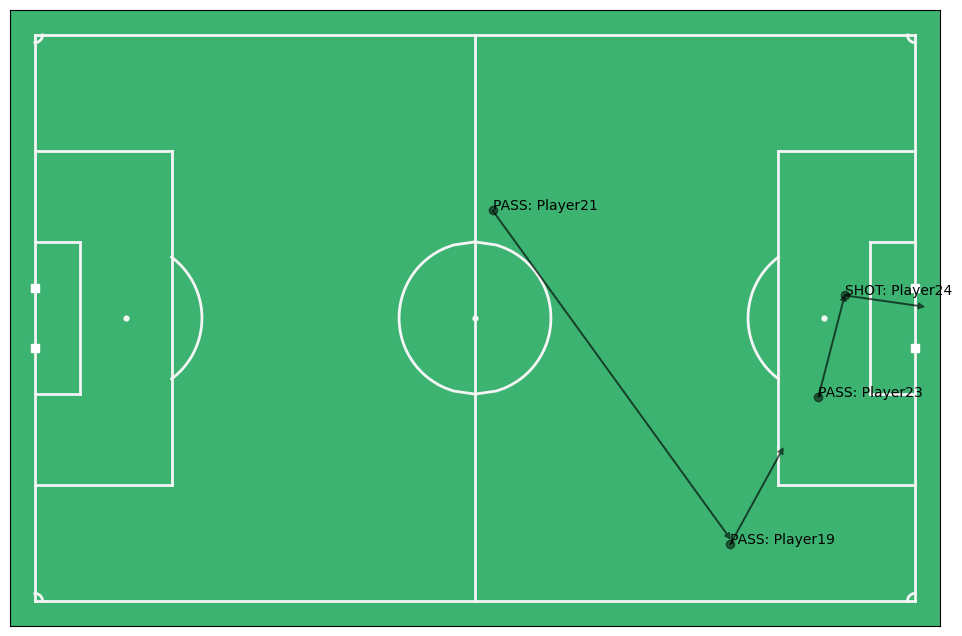

In [ ]:
# plot the 3 events leading up to the second goal
mviz.plot_events(
    events.loc[820:823], color="k", indicators=["Marker", "Arrow"], annotate=True
)

In [ ]:
# first get pitch control model parameters
params = mpc.default_model_params()
# find goalkeepers for offside calculation
GK_numbers = [mio.find_goalkeeper(tracking_home), mio.find_goalkeeper(tracking_away)]

(<Figure size 1200x800 with 1 Axes>, <Axes: >)

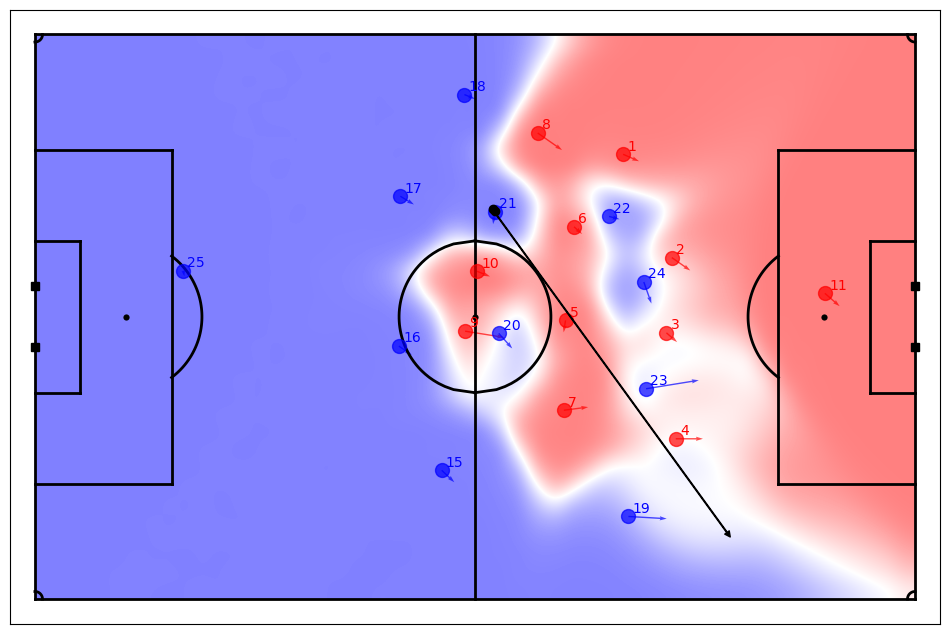

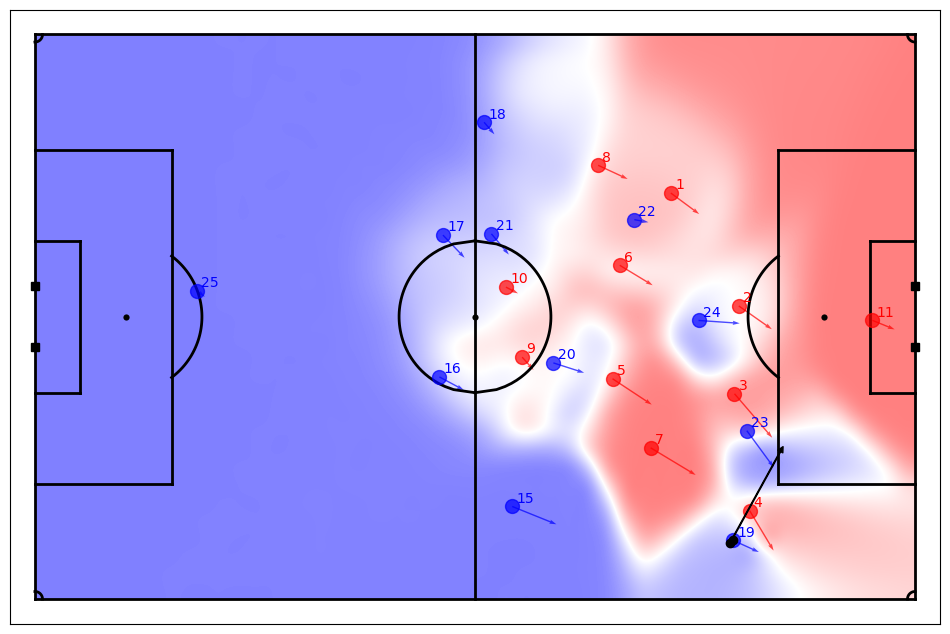

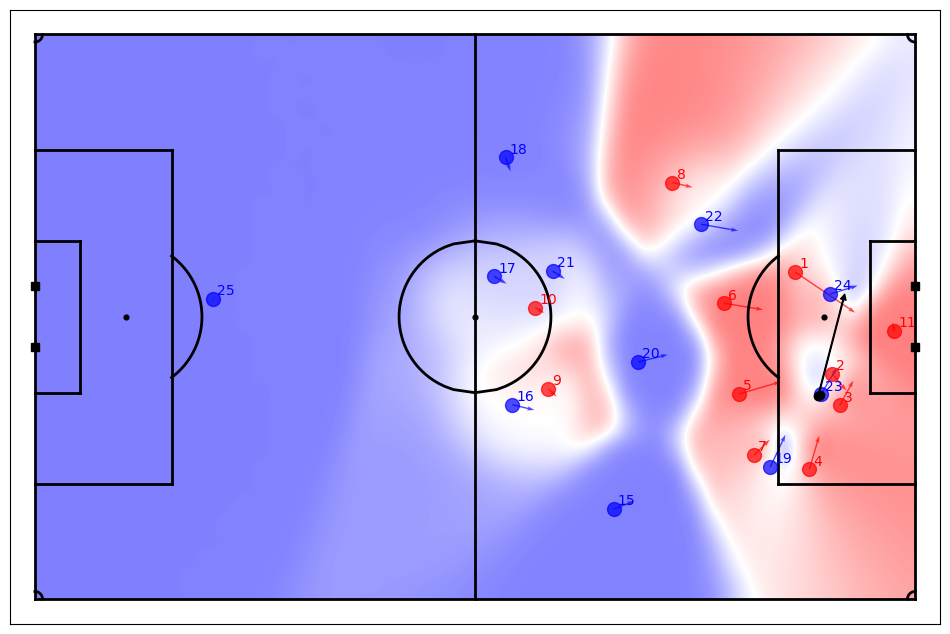

In [ ]:
# evaluated pitch control surface for first pass
PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
    820,
    events,
    tracking_home,
    tracking_away,
    params,
    GK_numbers,
    field_dimen=(
        106.0,
        68.0,
    ),
    n_grid_cells_x=50,
)
mviz.plot_pitchcontrol_for_event(
    820, events, tracking_home, tracking_away, PPCF, annotate=True
)
# evaluated pitch control surface for second pass
PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
    821,
    events,
    tracking_home,
    tracking_away,
    params,
    GK_numbers,
    field_dimen=(
        106.0,
        68.0,
    ),
    n_grid_cells_x=50,
)
mviz.plot_pitchcontrol_for_event(
    821, events, tracking_home, tracking_away, PPCF, annotate=True
)
# evaluated pitch control surface for third pass
PPCF, xgrid, ygrid = mpc.generate_pitch_control_for_event(
    822,
    events,
    tracking_home,
    tracking_away,
    params,
    GK_numbers,
    field_dimen=(
        106.0,
        68.0,
    ),
    n_grid_cells_x=50,
)
mviz.plot_pitchcontrol_for_event(
    822, events, tracking_home, tracking_away, PPCF, annotate=True
)

In [ ]:
# get all home passes
home_passes = events[(events["Type"].isin(["PASS"])) & (events["Team"] == "Home")]

# list for storing pass probablities
pass_success_probability = []

for i, row in home_passes.iterrows():
    pass_start_pos = np.array([row["Start X"], row["Start Y"]])
    pass_target_pos = np.array([row["End X"], row["End Y"]])
    pass_frame = row["Start Frame"]

    attacking_players = mpc.initialise_players(
        tracking_home.loc[pass_frame], "Home", params, GK_numbers[0]
    )
    defending_players = mpc.initialise_players(
        tracking_away.loc[pass_frame], "Away", params, GK_numbers[1]
    )
    Patt, Pdef = mpc.calculate_pitch_control_at_target(
        pass_target_pos, attacking_players, defending_players, pass_start_pos, params
    )

    pass_success_probability.append((i, Patt))

In [54]:
importlib.reload(mio)

<module 'Metrica_IO' from '/Users/hadrienstrichard/Documents/HEC 2024/football with ameya/football-tactical-analysis/Metrica_IO.py'>

Event following a risky (completed) pass
0.16032323299177284 BALL LOST
0.1613295457364337 CHALLENGE
0.21206157666402695 SHOT
0.31160841865474675 CHALLENGE
0.33190526185319935 SHOT
0.3370434729809066 CHALLENGE
0.3639283907689767 BALL LOST
0.4131562523163675 CHALLENGE
0.42042677463419303 PASS
0.431271262852387 CHALLENGE
0.44435098489184177 CHALLENGE
0.4478342580159542 PASS
0.45936651514837745 CHALLENGE
0.46181533356257215 SHOT
0.4680481708799845 CHALLENGE
0.476668457137286 PASS
0.48972755639125787 CHALLENGE
0.49008726464957086 CHALLENGE
0.4917205100922201 SHOT
0.5001349056944226 PASS


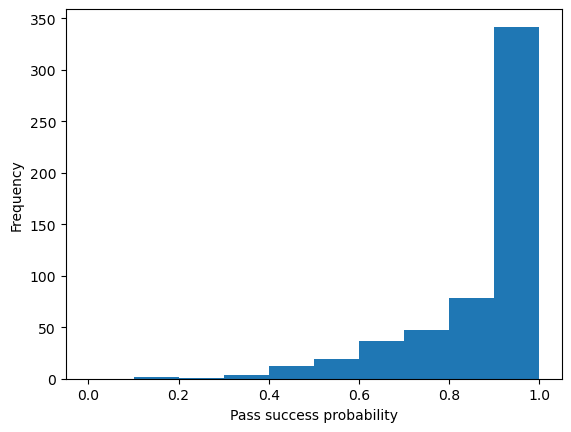

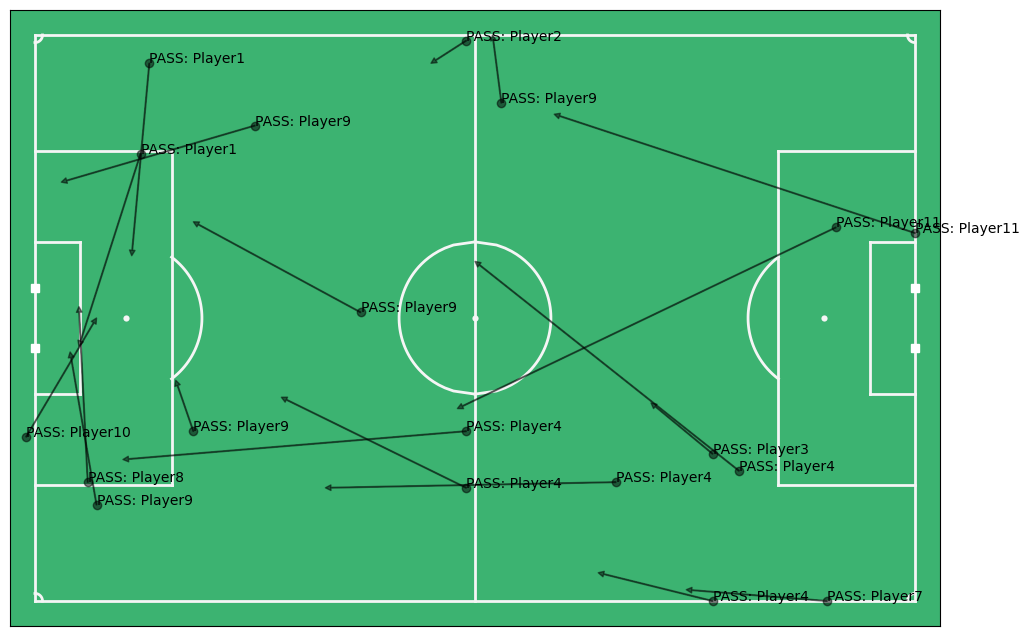

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.hist([p[1] for p in pass_success_probability], np.arange(0, 1.1, 0.1))
ax.set_xlabel("Pass success probability")
ax.set_ylabel("Frequency")

# sort the passes by pitch control probability
pass_success_probability = sorted(pass_success_probability, key=lambda x: x[1])

# identify the events corresponding to the most risky passes (pitch control < 0.5)
risky_passes = events.loc[[p[0] for p in pass_success_probability if p[1] < 0.5]]

# plot the events
mviz.plot_events(risky_passes, color="k", indicators=["Marker", "Arrow"], annotate=True)

# Print events that followed those risky passes
print("Event following a risky (completed) pass")
for p in pass_success_probability[:20]:
    outcome = events.loc[p[0] + 1].Type
    print(p[1], outcome)

In [ ]:
import matplotlib.pyplot as plt
import Metrica_Viz as mviz
import os

# Folder to store images
output_folder = "frame_images"
os.makedirs(output_folder, exist_ok=True)

# How many frames to render? (test sample)
frame_sample = 250  # Change to len(tracking_home) for full match

for i, frame in enumerate(tracking_home.iloc[:frame_sample].index):
    # Get data at this frame
    fig, ax = mviz.plot_pitch(field_dimen=(106, 68), field_color="green")

    mviz.plot_frame(tracking_home.loc[frame], tracking_away.loc[frame], figax=(fig, ax))

    # Add time display
    time_sec = tracking_home.loc[frame]["Time [s]"]
    min_ = int(time_sec // 60)
    sec_ = int(time_sec % 60)
    ax.text(-50, 40, f"{min_:02}:{sec_:02}", color="white", fontsize=14)

    # Save image
    fig.savefig(f"{output_folder}/frame_{i:05d}.png", dpi=100)
    plt.close(fig)

print(f"✅ Saved {frame_sample} frames to {output_folder}/")


✅ Saved 250 frames to frame_images/


In [ ]:
from PIL import Image
import glob

# Load and sort frames
frame_files = sorted(glob.glob("frame_images/frame_*.png"))
frames = [Image.open(f) for f in frame_files]

# Save as GIF with 4x speed
frames[0].save(
    "full_match.gif", save_all=True, append_images=frames[1:], duration=20, loop=0
)

print("✅ Saved full_match.gif")


✅ Saved full_match.gif


In [ ]:
import numpy as np


def calculate_pitch_control_grid(
    attacking_players,
    defending_players,
    field_dimen=(106.0, 68.0),
    n_grid_cells_x=50,
    params=None,
):
    """
    Calculates the pitch control surface over the whole field at a given moment.

    Returns:
        PPCF: pitch control probability surface (2D grid)
        xgrid, ygrid: grid coordinates
    """
    if params is None:
        params = mpc.default_model_params()

    n_grid_cells_y = int(n_grid_cells_x * field_dimen[1] / field_dimen[0])
    dx = field_dimen[0] / n_grid_cells_x
    dy = field_dimen[1] / n_grid_cells_y

    xgrid = np.linspace(
        -field_dimen[0] / 2.0 + dx / 2.0,
        field_dimen[0] / 2.0 - dx / 2.0,
        n_grid_cells_x,
    )
    ygrid = np.linspace(
        -field_dimen[1] / 2.0 + dy / 2.0,
        field_dimen[1] / 2.0 - dy / 2.0,
        n_grid_cells_y,
    )

    PPCF = np.zeros((n_grid_cells_y, n_grid_cells_x))

    for i, y in enumerate(ygrid):
        for j, x in enumerate(xgrid):
            target_position = np.array([x, y])
            Patt, _ = mpc.calculate_pitch_control_at_target(
                target_position,
                attacking_players,
                defending_players,
                np.array([0, 0]),
                params,
            )
            PPCF[i, j] = Patt

    return PPCF, xgrid, ygrid


In [ ]:
import Metrica_PitchControl as mpc
import Metrica_IO as mio
import matplotlib.pyplot as plt
import os

# Output folder
output_folder = "frame_images_pitchcontrol"
os.makedirs(output_folder, exist_ok=True)

# Load pitch control model params
params = mpc.default_model_params()

# Get GK jersey numbers
GK_numbers = [mio.find_goalkeeper(tracking_home), mio.find_goalkeeper(tracking_away)]


In [ ]:
from matplotlib import cm  # for colormap

frame_sample = 250  # limit for testing

for i, frame in enumerate(tracking_home.iloc[:frame_sample].index):
    try:
        # Player objects for this frame
        attacking_players = mpc.initialise_players(
            tracking_home.loc[frame], "Home", params, GK_numbers[0]
        )
        defending_players = mpc.initialise_players(
            tracking_away.loc[frame], "Away", params, GK_numbers[1]
        )

        # Calculate pitch control
        PPCF, xgrid, ygrid = calculate_pitch_control_grid(
            attacking_players,
            defending_players,
            field_dimen=(106.0, 68.0),
            n_grid_cells_x=50,
            params=params,
        )

        # Create pitch
        fig, ax = mviz.plot_pitch(field_dimen=(106, 68), field_color="green")

        # Show pitch control surface as heatmap
        ax.imshow(
            np.flipud(PPCF),  # flip y-axis
            extent=(-53, 53, -34, 34),
            interpolation="spline36",
            vmin=0.0,
            vmax=1.0,
            cmap=cm.bwr,
            alpha=0.5,
        )

        # Plot players and ball
        mviz.plot_frame(
            tracking_home.loc[frame], tracking_away.loc[frame], figax=(fig, ax)
        )

        # Add clock
        time_sec = tracking_home.loc[frame]["Time [s]"]
        min_ = int(time_sec // 60)
        sec_ = int(time_sec % 60)
        ax.text(-50, 40, f"{min_:02}:{sec_:02}", color="white", fontsize=14)

        # Save frame
        fig.savefig(f"{output_folder}/frame_{i:05d}.png", dpi=100)
        plt.close(fig)

    except Exception as e:
        print(f"⚠️ Skipping frame {frame} due to error: {e}")


In [ ]:
frame_files = sorted(glob.glob("frame_images_pitchcontrol/frame_*.png"))

frames = [Image.open(f) for f in frame_files]

# Save as GIF with 4x speed
frames[0].save(
    "pitch_control.gif", save_all=True, append_images=frames[1:], duration=20, loop=0
)

print("✅ Saved pitch_control.gif")


✅ Saved pitch_control.gif


In [129]:
tracking_home

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_6_speed,Home_7_vx,Home_7_vy,Home_7_speed,Home_8_vx,Home_8_vy,Home_8_speed,Home_9_vx,Home_9_vy,Home_9_speed
Frame,,,,,,,,,,,,,,,,,,,,,
1,1,0.04,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0.08,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0.12,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0.16,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,0.20,46.9315,-0.28084,15.70072,14.54860,18.81712,4.89396,21.07492,-3.81208,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2,5646.08,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,1.271789,0.0,0.0,0.0,0.0,0.0,0.0,1.378000,1.296857,1.892280
141153,2,5646.12,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,1.050501,0.0,0.0,0.0,0.0,0.0,0.0,1.544571,0.981143,1.829848
141154,2,5646.16,46.3379,0.84524,12.19106,-23.55792,29.08852,-5.87860,24.22948,-12.09788,...,0.913685,0.0,0.0,0.0,0.0,0.0,0.0,1.533214,0.979929,1.819617


In [ ]:
import os
from PIL import Image
import numpy as np

fps = 25
clip_duration_seconds = 20
clip_frames = clip_duration_seconds * fps
params = mpc.default_model_params()
GK_numbers = [mio.find_goalkeeper(tracking_home), mio.find_goalkeeper(tracking_away)]

# Output folders
frame_folder = "goal_clip_frames"
gif_folder = "goal_gifs"
os.makedirs(frame_folder, exist_ok=True)
os.makedirs(gif_folder, exist_ok=True)

for idx, (event_index, goal) in enumerate(goals.iterrows()):
    goal_frame = int(goal["Start Frame"])
    start_frame = max(goal_frame - clip_frames + 50, 0)  # Avoid going below 0

    print(f"🎥 Processing Goal {idx + 1} ({goal['Team']}) at frame {goal_frame}...")

    saved_frames = []

    for i, frame in enumerate(range(start_frame, goal_frame + 50)):
        try:
            # Get players
            attacking_players = mpc.initialise_players(
                tracking_home.loc[frame], "Home", params, GK_numbers[0]
            )
            defending_players = mpc.initialise_players(
                tracking_away.loc[frame], "Away", params, GK_numbers[1]
            )

            # Compute pitch control
            PPCF, xgrid, ygrid = calculate_pitch_control_grid(
                attacking_players,
                defending_players,
                field_dimen=(106.0, 68.0),
                n_grid_cells_x=50,
                params=params,
            )

            # Plot pitch and PPCF
            fig, ax = mviz.plot_pitch(field_dimen=(106, 68), field_color="green")
            ax.imshow(
                np.flipud(PPCF),
                extent=(-53, 53, -34, 34),
                interpolation="spline36",
                vmin=0.0,
                vmax=1.0,
                cmap="bwr",
                alpha=0.5,
            )

            mviz.plot_frame(
                tracking_home.loc[frame], tracking_away.loc[frame], figax=(fig, ax)
            )

            # Add clock
            time_sec = tracking_home.loc[frame]["Time [s]"]
            min_ = int(time_sec // 60)
            sec_ = int(time_sec % 60)
            ax.text(-50, 40, f"{min_:02}:{sec_:02}", color="white", fontsize=14)

            # Save temporary frame
            frame_path = f"{frame_folder}/goal{idx}_frame_{i:04d}.png"
            fig.savefig(frame_path, dpi=100)
            saved_frames.append(frame_path)
            plt.close(fig)

        except Exception as e:
            print(f"⚠️ Frame {frame} skipped: {e}")

    # Stitch frames into GIF
    images = [Image.open(f) for f in saved_frames]
    if images:
        gif_path = f"{gif_folder}/goal_{idx + 1}_{goal['Team']}.gif"
        images[0].save(
            gif_path,
            save_all=True,
            append_images=images[1:],
            duration=40,  # 25 FPS
            loop=0,
        )
        print(f"✅ Saved: {gif_path}")

print("✅ All goal clips generated.")


🎥 Processing Goal 1 (Home) at frame 12202...
✅ Saved: goal_gifs/goal_1_Home.gif
🎥 Processing Goal 2 (Away) at frame 53049...
✅ Saved: goal_gifs/goal_2_Away.gif
🎥 Processing Goal 3 (Home) at frame 73983...
✅ Saved: goal_gifs/goal_3_Home.gif
🎥 Processing Goal 4 (Away) at frame 115009...
✅ Saved: goal_gifs/goal_4_Away.gif
🎥 Processing Goal 5 (Home) at frame 121027...
✅ Saved: goal_gifs/goal_5_Home.gif
✅ All goal clips generated.


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# Initialize list to store time series
control_over_time = []

# Loop through the whole match (or limit for speed)
frame_range = tracking_home.index[:10000]  # e.g., first 10000 frames = 6.6 mins

params = mpc.default_model_params()
GK_numbers = [mio.find_goalkeeper(tracking_home), mio.find_goalkeeper(tracking_away)]

for frame in tqdm(frame_range):
    try:
        # Initialize players
        att_players = mpc.initialise_players(
            tracking_home.loc[frame], "Home", params, GK_numbers[0]
        )
        def_players = mpc.initialise_players(
            tracking_away.loc[frame], "Away", params, GK_numbers[1]
        )

        # Calculate pitch control
        PPCF, _, _ = calculate_pitch_control_grid(att_players, def_players)

        # Home control = mean PPCF
        mean_control = np.mean(PPCF)
        time_sec = tracking_home.loc[frame]["Time [s]"]

        control_over_time.append((frame, time_sec, mean_control))

    except:
        continue

# Convert to DataFrame
control_df = pd.DataFrame(
    control_over_time, columns=["Frame", "Time [s]", "HomeControl"]
)


 13%|█▎        | 1340/10000 [28:38<3:13:59,  1.34s/it]

In [ ]:
import matplotlib.pyplot as plt

# Get goal times
goal_times = events[
    (events["Type"] == "SHOT") & (events["Subtype"].str.contains("-GOAL", na=False))
]["Time [s]"]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    control_df["Time [s]"], control_df["HomeControl"], label="Home Pitch Control (%)"
)
for g in goal_times:
    plt.axvline(g, color="red", linestyle="--", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Controlled % of Pitch")
plt.title("Home Team Pitch Control Over Time (with Goals)")
plt.legend()
plt.tight_layout()
plt.show()


ValueError: Could not interpret value `Pass Success` for `x`. An entry with this name does not appear in `data`.

In [ ]:
import imageio.v2 as imageio
import os
import glob

# Folder with GIFs
gif_folder = "goal_gifs"
mp4_folder = "goal_videos"
os.makedirs(mp4_folder, exist_ok=True)

# Get all GIF files
gif_files = sorted(glob.glob(os.path.join(gif_folder, "*.gif")))

# Convert each GIF to MP4
for gif_path in gif_files:
    gif_name = os.path.splitext(os.path.basename(gif_path))[0]
    mp4_path = os.path.join(mp4_folder, f"{gif_name}.mp4")

    reader = imageio.get_reader(gif_path)
    fps = reader.get_meta_data()["duration"]
    writer = imageio.get_writer(mp4_path, fps=1000 / fps)

    for frame in reader:
        writer.append_data(frame)

    writer.close()

converted_files = os.listdir(mp4_folder)
converted_files.sort()
converted_files[:5]  # Show a few converted file names


In [ ]:
import numpy as np
import pandas as pd

# Model params & GK numbers
params = mpc.default_model_params()
GK_numbers = [mio.find_goalkeeper(tracking_home), mio.find_goalkeeper(tracking_away)]

# Filter home passes
home_passes = events[
    (events["Type"] == "PASS")
    & (events["Team"] == "Home")
    & (~events["End X"].isna())  # Make sure there's an end location
].copy()

# For storing boundary passes
boundary_passes = []

for i, row in home_passes.iterrows():
    frame = row["Start Frame"]
    try:
        # Initialize players
        att_players = mpc.initialise_players(
            tracking_home.loc[frame], "Home", params, GK_numbers[0]
        )
        def_players = mpc.initialise_players(
            tracking_away.loc[frame], "Away", params, GK_numbers[1]
        )

        # Target position
        pass_target = np.array([row["End X"], row["End Y"]])
        pass_start = np.array([row["Start X"], row["Start Y"]])

        # Calculate PPCF at target
        Patt, _ = mpc.calculate_pitch_control_at_target(
            pass_target, att_players, def_players, pass_start, params
        )

        if 0.4 <= Patt <= 0.6:
            boundary_passes.append(
                {
                    "Frame": frame,
                    "Time [s]": row["Time [s]"],
                    "Patt": Patt,
                    "End X": row["End X"],
                    "End Y": row["End Y"],
                    "Event Index": i,
                }
            )

    except Exception as e:
        continue

boundary_df = pd.DataFrame(boundary_passes)


In [ ]:
# Already computed earlier: control_df with ["Frame", "Time [s]", "HomeControl"]

goal_times = events[
    (events["Type"] == "SHOT") & (events["Subtype"].str.contains("-GOAL", na=False))
]["Time [s]"]

plt.figure(figsize=(14, 6))
plt.plot(control_df["Time [s]"], control_df["HomeControl"], label="Home Pitch Control")
for g in goal_times:
    plt.axvline(
        g,
        color="red",
        linestyle="--",
        label="Goal" if "Goal" not in plt.gca().get_legend_handles_labels()[1] else "",
    )
plt.xlabel("Time (s)")
plt.ylabel("Pitch Controlled by Home (%)")
plt.title("Pitch Control Over Time (Goals marked)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("Event following boundary passes:\n")
for i, row in boundary_df.iterrows():
    next_event_idx = row["Event Index"] + 1
    if next_event_idx in events.index:
        outcome = events.loc[next_event_idx]["Type"]
        print(
            f"Frame {int(row['Frame'])} → Patt={row['Patt']:.2f} → Outcome: {outcome}"
        )
